
Sections:

1. Inferential Statistics

2. Sampling
* Population
* Sample
* Parameter
* Statistic
* Random sampling

3. Sampling Distribution

4. Central Limit Theorem

5. Confidence Intervals

6. Hypothesis Testing
* Null hypothesis
* Alternative hypothesis
* Significance level
* Test statistic
* p-value

7. Statistical Tests
* One-sample t-test
* Two-sample t-test
* Chi-square test


## 1.0 Inferential Statistics

Inferential statistics is the process of using data from a **sample** to make conclusions or estimates about a larger **population**.

While descriptive statistics focuses on summarizing the data we have, inferential statistics uses sample data to learn about the population.

For example, instead of studying the salaries of all employees in a population, we can select a sample of employees, analyze their salaries, and use the results to make conclusions about the larger population.

In this notebook, we will use the employee data to demonstrate key concepts of inferential statistics, including **sampling, sampling distributions, the Central Limit Theorem, confidence intervals, hypothesis testing, correlation, and regression**.


## 2.0 Sampling

Sampling is the process of selecting a smaller group of observations from a larger population for analysis.

In inferential statistics, we use a sample to learn about the population because studying every member of a population may require more time and resources.

A good sample should represent the population as closely as possible. If the sample does not properly represent the population, the results may be affected by **sample bias**.

### Population, Sample, Parameter and Statistic

population, sample, parameter, and statistic concept

| Concept        | Meaning                                         | Example                |
| -------------- | ----------------------------------------------- | ---------------------- |
| **Population** | The entire group being studied                  | 10,000 employees       |
| **Sample**     | A smaller group selected from the population    | 200 employees          |
| **Parameter**  | A numerical value that describes the population | Population mean salary |
| **Statistic**  | A numerical value calculated from the sample    | Sample mean salary     |

### Population

A **population** is the entire group of individuals or observations that we are interested in studying.

In this analysis, the population consists of **10,000 employees** in the employee dataset.

### Sample

A **sample** is a smaller group selected from the population for analysis.

For this analysis, we select a sample of **200 employees** from the population of 10,000 employees.

### Parameter

A **parameter** is a numerical value that describes a characteristic of the population.

For example, the **population mean salary** is a parameter because it describes the average salary of all employees in the population.

### Statistic

A **statistic** is a numerical value calculated from a sample.

For example, the **sample mean salary** is a statistic because it is calculated using the salaries of the selected sample of employees.

Statistics are used to estimate population parameters.


#### Why Sampling is Important

Sampling involves selecting a smaller group of observations from a population for analysis.

Studying the entire population may require more time and resources, so a sample can be used to make estimates and draw conclusions about the entire population.

For a sample to provide useful information about the population, it should be selected in a way that reduces bias and gives different members of the population a fair chance of being included.


### Random Sampling

Random sampling is a method of selecting members of a population at random, giving each member an equal chance of being selected.

Random sampling helps reduce sample bias and gives the sample a better chance of representing the population.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data
df = pd.read_csv("./Data/Employers_data.csv")

#### Creating a Random Sample from the Employee Data

In [3]:
# Select a random sample of 200 employees
sample_df = df.sample(n=200, random_state=42)

# Display the first five rows
sample_df.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
6252,6253,Paula Hernandez,41,Female,Engineering,Manager,18,Master,San Francisco,135000
4684,4685,Mary Hodges,29,Female,HR,Analyst,6,Master,New York,70000
1731,1732,Larry Menzies,25,Male,Finance,Analyst,4,Bachelor,Austin,65000
4742,4743,James Wilson,35,Male,Engineering,Manager,12,Master,San Francisco,125000
4521,4522,Donald Crawford,44,Male,Engineering,Manager,21,Master,Chicago,140000


* The **random_state=42** makes the sampling reproducible, meaning we will get the same sample each time we run the code.

In [4]:
# Check the sample size
sample_df.shape

(200, 10)

In [5]:
# Compare the population and sample
print("Population size:", len(df))
print("Sample size:", len(sample_df))

Population size: 10000
Sample size: 200


**Observation**

A random sample of 200 employees has been selected from the population of 10,000 employees.

We will use this sample to demonstrate **sampling distributions**, **confidence intervals**, and **hypothesis testing.**

## 3.0 Sampling Distribution

A **sampling distribution** is the distribution of a sample statistic calculated from many different samples taken from the same population.

For example, if we repeatedly select samples of employees and calculate the mean salary for each sample, the collection of those Sample Means forms a **sampling distribution**.

A sampling distribution helps us understand how samples vary from one sample to another.


* Since our population contains 10,000 employees, we can repeatedly take random samples and calculate the mean salary for each sample.


In [6]:
# Let's take 1,000 samples, with each sample containing 200 employees.
sample_means = []

for i in range(1000):
    sample = df.sample(n=200)
    sample_means.append(sample["Salary"].mean())


# converting the samples into a DataFrame
sampling_distribution = pd.DataFrame({
    "Sample_Mean_Salary": sample_means
})

sampling_distribution.head()

,Sample_Mean_Salary
0,114350.0
1,117175.0
2,115125.0
3,117075.0
4,114150.0


In [7]:
sampling_distribution.shape

(1000, 1)

* We have 1,000 Sample Means from the distribution.

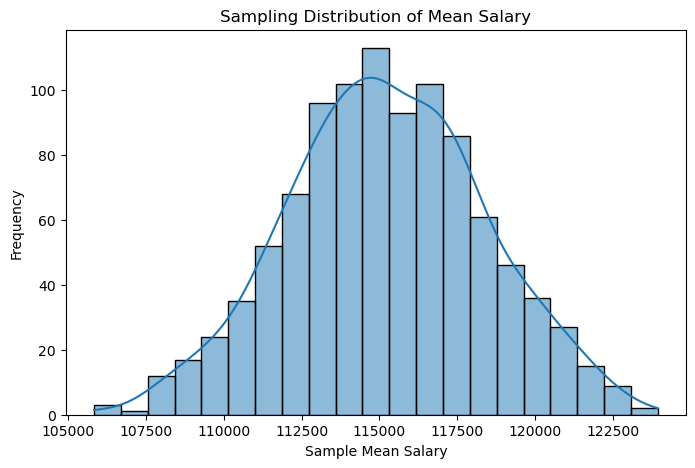

In [8]:
# Visualizing the Sampling Distribution for the sample means
plt.figure(figsize=(8, 5))

sns.histplot(
    data=sampling_distribution,
    x="Sample_Mean_Salary",
    kde=True
)

plt.title("Sampling Distribution of Mean Salary")
plt.xlabel("Sample Mean Salary")
plt.ylabel("Frequency")
plt.show()

#### Comparing the Mean and Standard Deviation of the Sample Means with the Population Mean

For samples

In [9]:
sample_mean = sampling_distribution["Sample_Mean_Salary"].mean()
sample_std = sampling_distribution["Sample_Mean_Salary"].std()

print("Sample Mean Salary:", sample_mean)
print("Sample Standard Deviation:", sample_std)

Sample Mean Salary: 115215.225
Sample Standard Deviation: 3160.8958519637818


For Population

In [10]:
population_mean = df["Salary"].mean()
population_std = df["Salary"].std()

print("Population Mean Salary:", population_mean)
print("Population Standard Deviation:", population_std)

Population Mean Salary: 115381.5
Population Standard Deviation: 46066.139046664925


#### Observation

* The population mean salary is **115,381.50**, while the Sample Mean Salary  is **115,357.0**.
* The two values are very close, showing that the mean of the sample means provides a good estimate of the entire employee population mean.
* The population standard deviation is 46,066.14, while the sample standard deviaton is 3,107.30.
* The sample means vary less because each mean is calculated from a sample of 200 employees.
* This shows that larger samples produce more stable estimates of the population mean.


###  Why Sample Means Vary

Different random samples contain different employees. Because of this, the mean calculated from one sample may be different from the mean calculated from another sample.

For example:

* Sample 1 may have a mean salary of 116,000.
* Sample 2 may have a mean salary of 113,500.
* Sample 3 may have a mean salary of 115,800.

When many samples are taken, these sample means form a distribution around the population mean.

The frequency distribution of a sample statistic shows how that statistic can vary from sample to sample. This is the basis of the sampling distribution.


## 4.0 Central Limit Theorem

* The Central Limit Theorem (CLT) states that when we take many samples of a sufficiently large size and calculate their means, the distribution of those sample means tends to have a bell-shaped, approximately normal distribution.

* The CLT is important because it allows us to use sample data to make conclusions about a population.

* It provides the foundation for methods such as confidence intervals and hypothesis testing

In this analysis, we used 1,000 samples of 200 employees. The distribution of their sample means demonstrates how the Central Limit Theorem works.

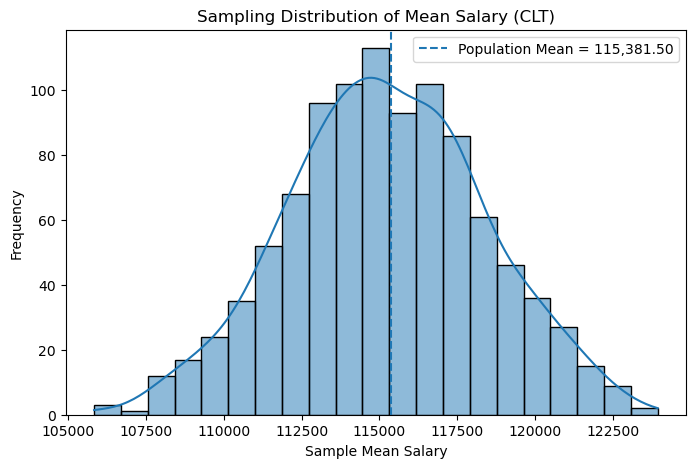

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=sampling_distribution,
    x="Sample_Mean_Salary",
    kde=True
)

plt.axvline(
    population_mean,
    linestyle="--",
    label=f"Population Mean = {population_mean:,.2f}"
)

plt.title("Sampling Distribution of Mean Salary (CLT)")
plt.xlabel("Sample Mean Salary")
plt.ylabel("Frequency")
plt.legend()
plt.show()

From the graph
* The sample Means form a distribution that is approximately bell-shaped.
* **The distribution is centered close to the population mean salary**.
* This demonstrates the **Central Limit Theorem** using the employee salaries data.
* The CLT helps explain why sample means can be used to make inferences about a population.


The standard deviation of the sampling distribution represents the variability of the sample means. This is known as the standard error

As the sample size increases, the sampling distribution of the mean tends to become more stable and its standard error becomes smaller.


### 5.0 Confidence Intervals

A confidence interval is a range of values used to estimate a population parameter, such as the population mean.

A sample mean gives us an estimate of the population mean, but it may not be exactly equal to the true population mean. A confidence interval gives us a range around the sample mean to account for this difference.

For example, instead of using only the sample mean salary to estimate the average salary of all employees, we can calculate a range that is expected to contain the population mean.

The confidence level describes how often confidence intervals created using the same method are expected to contain the population parameter.

For example, a 95% confidence level means that if we repeatedly took samples from the same population and calculated confidence intervals in the same way, about 95% of those intervals would be expected to contain the population mean.

The width of a confidence interval depends on:

Sample size
Variation in the data
Confidence level

A higher confidence level produces a wider interval, while a larger sample generally produces a narrower interval.

In [12]:
# Calculate the 95% confidence interval
confidence_interval = (
    np.percentile(sampling_distribution["Sample_Mean_Salary"], 2.5),
    np.percentile(sampling_distribution["Sample_Mean_Salary"], 97.5)
)

# Get the confidence interval limits
lower_bound, upper_bound = confidence_interval



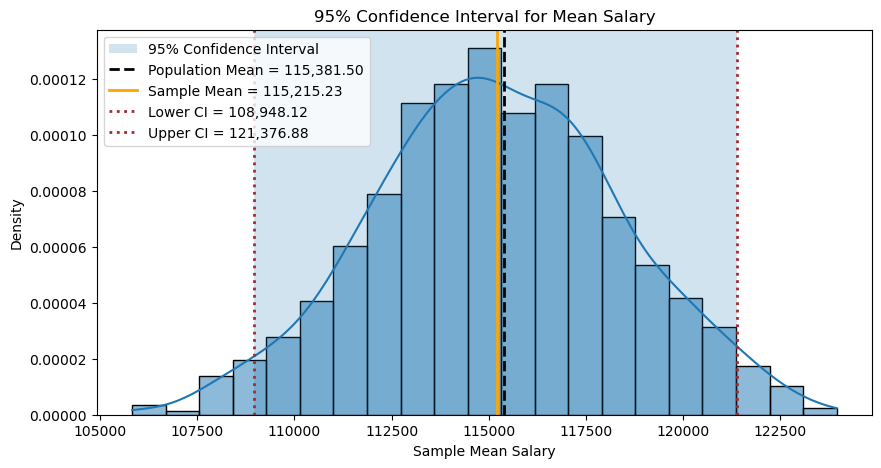

In [13]:
plt.figure(figsize=(10, 5))

# Bell-shaped sampling distribution
sns.histplot(
    sampling_distribution["Sample_Mean_Salary"],
    kde=True,
    stat="density"
)

# Shade the 95% confidence interval
plt.axvspan(
    lower_bound,
    upper_bound,
    alpha=0.2,
    label="95% Confidence Interval"
)

# Population mean
plt.axvline(
    population_mean,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Population Mean = {population_mean:,.2f}"
)

# Sample mean
plt.axvline(
    sample_mean,
    color="orange",
    linestyle="-",
    linewidth=2,
    label=f"Sample Mean = {sample_mean:,.2f}"
)

# Lower confidence limit
plt.axvline(
    lower_bound,
    color="brown",
    linestyle=":",
    linewidth=2,
    label=f"Lower CI = {lower_bound:,.2f}"
)

# Upper confidence limit
plt.axvline(
    upper_bound,
    color="brown",
    linestyle=":",
    linewidth=2,
    label=f"Upper CI = {upper_bound:,.2f}"
)

plt.title("95% Confidence Interval for Mean Salary")
plt.xlabel("Sample Mean Salary")
plt.ylabel("Density")
plt.legend()
plt.show()

* From the graph, the **sample mean salary** is 115,346.52 , while the **population mean salary** is 115,381.50 The 95% confidence interval ranges from (108,698.12.75 to 121,853.12) and the population mean falls within this interval.
* Therefore, we are 95% confident that the interval 108,698.12.75 - 121,853.12 captures the true population mean salary. 

## 6.0 Hypothesis Testing

**Hypothesis testing** is a statistical method used to determine whether there is enough evidence in a sample to support a claim about a population.

A hypothesis test begins with a **null hypothesis**, which represents the assumption that there is no meaningful effect, difference, or relationship.

We then use sample data to determine whether the observed result would be unusual if the null hypothesis were true.

The basic process is:

1. State the **null hypothesis**.
2. State the **alternative hypothesis**.
3. Choose a **significance level**.
4. Calculate a **test statistic**.
5. Calculate the **p-value**.
6. Compare the p-value with the significance level.
7. Make a decision about the null hypothesis.

The main goal is not to prove that a hypothesis is true. Instead, we determine whether the sample provides enough evidence to **reject the null hypothesis** or whether there is **not enough evidence to reject it**.


### 6.1 Null and Alternative Hypotheses

A **null hypothesis (H₀)** is the starting assumption that there is **no meaningful effect, difference, or relationship**. Any difference observed in the sample is assumed to be due to chance.

An **alternative hypothesis (H₁)** is the opposite of the null hypothesis. It states that there **is a meaningful effect, difference, or relationship**.

In hypothesis testing, we start by assuming that the null hypothesis is true. We then use the sample data to determine whether the result is unusual enough to reject it.

**Example using employee salaries:**

Suppose we want to determine whether the average employee salary is different from **100,000**.

* **Null hypothesis (H₀):** The average employee salary is 100,000.
* **Alternative hypothesis (H₁):** The average employee salary is different from 100,000.

The test will help us decide whether the sample provides enough evidence to reject the null hypothesis.


### 6.2 Significance Level (α)

The **significance level (α)** is the threshold used to decide whether a result is statistically significant.

It represents the level of evidence required to reject the null hypothesis.

A common significance level is **0.05 (5%)**.

The decision is based on the p-value:

* If **p-value ≤ 0.05**, reject the null hypothesis.
* If **p-value > 0.05**, fail to reject the null hypothesis.

For example, if a hypothesis test gives a p-value of **0.02**, it is below 0.05. We would reject the null hypothesis and conclude that there is enough evidence of a significant difference.

The significance level is chosen **before** conducting the hypothesis test.


### 6.3 Type I and Type II Errors

Hypothesis testing can lead to two types of errors.

**Type I Error**

A **Type I error** occurs when we reject the null hypothesis even though it is actually true.


**Example:**
We conclude that the average employee salary is different from 100,000 when the true average salary is actually 100,000.

**Type II Error**

A **Type II error** occurs when we fail to reject the null hypothesis even though it is actually false.


**Example:**
We conclude that there is not enough evidence that the average employee salary is different from 100,000 when the true average salary is actually different.

| Error             | What happens                           |
| ----------------- | -------------------------------------- |
| **Type I Error**  | Reject a true null hypothesis          |
| **Type II Error** | Fail to reject a false null hypothesis |

These errors are important because a hypothesis test is based on sample data, so there is always a possibility of making an incorrect decision.


### 6.4 Test Statistic

A **test statistic** is a value calculated from sample data and used to determine how different the sample result is from what we would expect if the null hypothesis were true.

It helps us measure the difference between the observed result and the value stated in the null hypothesis.

For example, if the null hypothesis states that the average employee salary is **100,000**, the test statistic measures how far the sample mean is from 100,000 while also taking the variation in the sample into account.

The test statistic is then used to calculate the **p-value**, which helps us decide whether to reject or fail to reject the null hypothesis.


### 6.5 P-value
The p-value tells us how likely it is to get the result observed in the sample, if the null hypothesis is true.

The p-value is compared with the **significance level (α)**:

* If **p-value ≤ 0.05**, reject the null hypothesis.
* If **p-value > 0.05**, fail to reject the null hypothesis.

**Example using employee salaries:**

Suppose the null hypothesis states that the average employee salary is **100,000**.

If the test produces a very small p-value, it means that getting a result different from 100,000 would be unlikely if the null hypothesis were true.

This gives us evidence against the null hypothesis.

A small p-value does not prove that the alternative hypothesis is true. It only shows that the observed result is unlikely under the null hypothesis.


### 7.1 One-Sample t-test

A **one-sample t-test** is used to determine whether the average (mean) of **a single group** is significantly different from a given value.

It compares the sample mean with a given value and determines whether the difference is statistically significant.

**Example**

Suppose we want to find out whether the average employee salary is different from **100,000**.

We set the hypotheses:

* Null hypothesis (H₀): The average employee salary is 100,000.
* Alternative hypothesis (H₁): The average employee salary is different from 100,000.
Significance level: 0.05

After calculating the test statistic and p-value:

If p-value ≤ 0.05, reject H₀ and conclude that there is enough evidence that the average salary is different from 100,000.
If p-value > 0.05, fail to reject H₀ because there is not enough evidence to conclude that the average salary is different from 100,000.

The one-sample t-test is useful when comparing the mean of one group with a known or specified value.

### 7.2 Two-Sample t-Test

A **two-sample t-test** is used to compare the means of **two independent groups**.

It helps determine whether the difference between the two group means is statistically significant.

**Example**

Suppose we want to compare the average salaries of employees from two different departments **Finance** and **Engineering**.

* **Null hypothesis (H₀):** The average salaries of the two departments are equal.
* **Alternative hypothesis (H₁):** The average salaries of the two departments are different.
* **Significance level:** 0.05

After calculating the test statistic and p-value:

* If **p-value ≤ 0.05**, reject H₀ and conclude that there is enough evidence that the average salaries are different.
* If **p-value > 0.05**, fail to reject H₀ because there is not enough evidence that the average salaries are different.

The two-sample t-test is useful when comparing the means of two separate groups.


### 7.3 Chi-Square Test

A **chi-square test** is used to determine whether there is a relationship between **two categorical variables**.

It compares the values observed in the data with the values we would expect if there were no relationship between the variables.

**Example using the employee dataset:**

Suppose we want to determine whether **Department** and **Education_Level** are related.

* **Null hypothesis (H₀):** Department and Education Level are independent.
* **Alternative hypothesis (H₁):** Department and Education Level are related.
* **Significance level:** 0.05

After calculating the chi-square statistic and p-value:

* If **p-value ≤ 0.05**, reject H₀ and conclude that there is enough evidence of a relationship between the two variables.
* If **p-value > 0.05**, fail to reject H₀ because there is not enough evidence of a relationship.

The chi-square statistic shows how different the observed results are from the results we would expect if the two variables were not related.

### 8.0 Correlation
### 8.1 Relationship Between Variables

A **relationship between variables** shows how two variables change in relation to each other.

When one variable changes, the other may also change. There are three main types of correlation: 

* **Positive:** Both variables tend to increase together (As one variable increases, the other tends to increase.)
* **Negative:** As one variable tends to increase, the other tends to decreases.
* **No clear relationship:** Changes in one variable do not show a consistent pattern in the other.

**Example using the employee dataset:**

We can look at the relationship between **Experience_Years** and **Salary**.

If employees with more years of experience generally have higher salaries, there is a **positive relationship** between experience and salary.



### 8.2 Correlation Coefficient

The correlation coefficient tells us how strongly two numerical variables are related and their direction.

It ranges from **-1 to +1**:

* +1 means a perfect positive relationship.
* 0 means no linear relationship.
* -1 means a perfect negative relationship.

Values closer to +1 show a stronger positive relationship, while values closer to -1 show a stronger negative relationship.

**Example**

If the correlation coefficient between Experience_Years and Salary is 0.75, it shows a strong positive relationship. This means that employees with more experience tend to have higher salaries.


### 8.3 Correlation Matrix and Scatterplot

A correlation matrix shows the correlation between multiple numerical variables. Each value shows the degree and direction of the relationship between two variables.

A scatterplot is used to visually show the relationship between two numerical variable with each point representing one observation.

## 9.0 Regression

**Regression** is a statistical method used to study the relationship between variables and make predictions.

In **simple linear regression**, we use one independent variable to predict a dependent variable.(understand how changes in one variable can be used to estimate or predict another variable.)

For example, using the employee dataset:

* **Independent variable (X):** Experience_Years
* **Dependent variable (Y):** Salary

We can use years of experience to predict an employee's salary.

The simple linear regression equation is:

**Y = β₀ + β₁X**

Where:

* **Y** = predicted value
* **X** = independent variable
* **β₀** = intercept
* **β₁** = regression coefficient/ slope

The regression coefficient shows how much the predicted value of **Y** changes when **X** increases by one unit.

* A positive coefficient means the predicted value increases as the independent variable increases.
* A negative coefficient means the predicted value decreases as the independent variable increases.
* A coefficient close to 0 means there is little linear change in the predicted value.

### 10.0 ANOVA

**ANOVA (Analysis of Variance)** is a statistical test used to compare the means of **three or more groups**.

It helps determine whether the differences between the group means are large enough to suggest that the groups have different average values.

For example, using the employee dataset, we could compare the average **salary** across several departments.

* **Null hypothesis (H₀):** The average salaries of the departments are equal.
* **Alternative hypothesis (H₁):** At least one department has a different average salary.
* **Significance level:** 0.05

The ANOVA test produces an **F-statistic** and a **p-value**.

* If **p-value ≤ 0.05**, reject H₀ and conclude that there is enough evidence that the group means are not all equal.
* If **p-value > 0.05**, fail to reject H₀ because there is not enough evidence that the group means are different.

ANOVA is useful when comparing the means of **three or more groups**.
